# Cats vs Dogs Image Classification with a Convolutional Neural Network (CNN)

This notebook trains and evaluates a CNN on the Cats vs Dogs image dataset using a reproducible Keras/TensorFlow pipeline.

- **Dataset**: `training_set/` (~8 007 images) and `test_set/` (~2 025 images), split into `cats/` and `dogs/` subdirectories
- **Target encoding**: Cat = 0, Dog = 1 (alphabetical label inference)
- **Image size**: 64 × 64 pixels, rescaled to `[0, 1]`
- **Train augmentation**: horizontal flip, zoom (10 %), rotation (10°)
- **Random seeds**: `numpy` and `tensorflow` both fixed to 42

## 1) Import Libraries and Configure Reproducibility

Import all required libraries and set plotting preferences for clean, consistent outputs.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

TRAIN_DIR = Path("training_set")
TEST_DIR  = Path("test_set")
IMG_SIZE  = (64, 64)
BATCH     = 32
EPOCHS    = 20
CLASS_NAMES = ["Cat (0)", "Dog (1)"]

print(f"TensorFlow version : {tf.__version__}")
print(f"Training directory : {TRAIN_DIR.resolve()}")
print(f"Test directory     : {TEST_DIR.resolve()}")

2026-05-05 13:23:11.570339: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.16.2
Training directory : /Users/sebastianmachkovich/UW-Green Bay/CompSci_465/CNN-Image-Recognition/training_set
Test directory     : /Users/sebastianmachkovich/UW-Green Bay/CompSci_465/CNN-Image-Recognition/test_set


## 2) Dataset Overview

Count images per class and visualise the class distribution with a bar chart, then display a sample grid of images from each class.

In [2]:
train_cats = len(list((TRAIN_DIR / "cats").glob("*.jpg")))
train_dogs = len(list((TRAIN_DIR / "dogs").glob("*.jpg")))
test_cats  = len(list((TEST_DIR  / "cats").glob("*.jpg")))
test_dogs  = len(list((TEST_DIR  / "dogs").glob("*.jpg")))

print("Image counts")
print(f"  Training — Cats: {train_cats:>5},  Dogs: {train_dogs:>5},  Total: {train_cats + train_dogs:>5}")
print(f"  Test     — Cats: {test_cats:>5},  Dogs: {test_dogs:>5},  Total: {test_cats  + test_dogs:>5}")

Image counts
  Training — Cats:  4000,  Dogs:  4005,  Total:  8005
  Test     — Cats:  1011,  Dogs:  1012,  Total:  2023


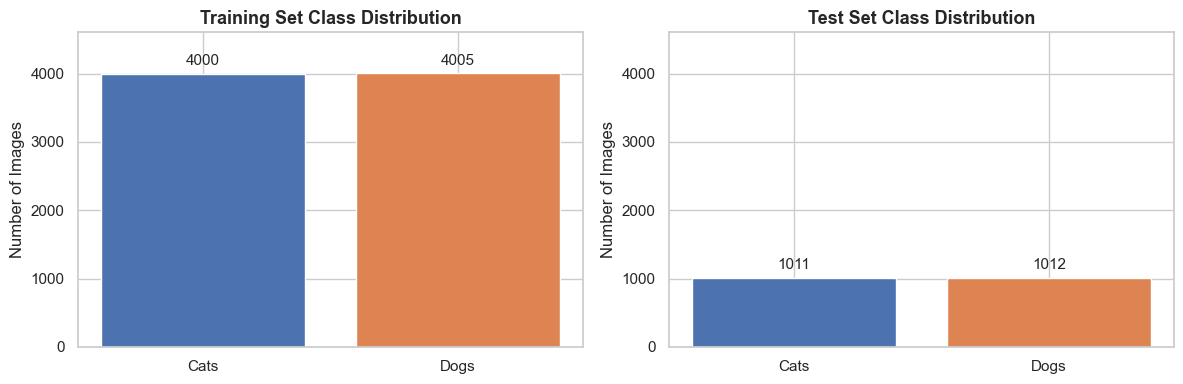

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, split, cats, dogs in zip(
    axes,
    ["Training Set", "Test Set"],
    [train_cats, test_cats],
    [train_dogs, test_dogs],
):
    bars = ax.bar(["Cats", "Dogs"], [cats, dogs], color=["#4C72B0", "#DD8452"], edgecolor="white")
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=11)
    ax.set_title(f"{split} Class Distribution", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Images")
    ax.set_ylim(0, max(train_cats, train_dogs) * 1.15)

plt.tight_layout()
plt.savefig("Class Distribution.png", dpi=150, bbox_inches="tight")
plt.show()

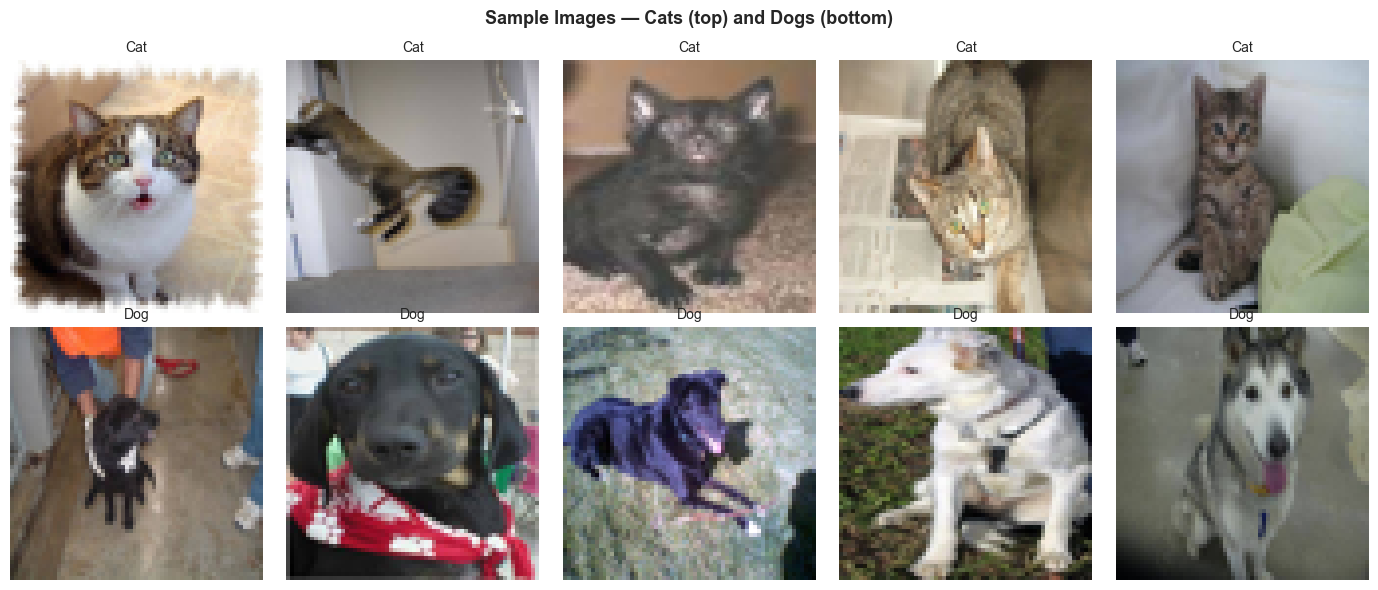

In [4]:
import random
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Images — Cats (top) and Dogs (bottom)", fontsize=13, fontweight="bold")

for col, img_path in enumerate(random.sample(list((TRAIN_DIR / "cats").glob("*.jpg")), 5)):
    axes[0, col].imshow(Image.open(img_path).resize(IMG_SIZE))
    axes[0, col].axis("off")
    axes[0, col].set_title("Cat", fontsize=10)

for col, img_path in enumerate(random.sample(list((TRAIN_DIR / "dogs").glob("*.jpg")), 5)):
    axes[1, col].imshow(Image.open(img_path).resize(IMG_SIZE))
    axes[1, col].axis("off")
    axes[1, col].set_title("Dog", fontsize=10)

plt.tight_layout()
plt.show()

## 3) Data Preprocessing and Augmentation

Images are resized to 64 × 64 and pixel values rescaled to `[0, 1]`.  
Training data is augmented with horizontal flips, small zoom, and slight rotation to improve generalisation.  
The test generator applies **only** rescaling — no augmentation — to get unbiased evaluation.

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10,
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    seed=42,
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    shuffle=False,
)

print(f"\nClass indices : {train_gen.class_indices}")
print(f"Training steps per epoch : {len(train_gen)}")
print(f"Test steps               : {len(test_gen)}")

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.

Class indices : {'cats': 0, 'dogs': 1}
Training steps per epoch : 251
Test steps               : 64


## 4) Model Architecture

A three-block CNN is used:

| Block | Layer | Details |
|-------|-------|---------|
| 1 | Conv2D + MaxPool | 32 filters, 3×3, ReLU → 2×2 pool |
| 2 | Conv2D + MaxPool | 64 filters, 3×3, ReLU → 2×2 pool |
| 3 | Conv2D + MaxPool | 128 filters, 3×3, ReLU → 2×2 pool |
| — | Flatten → Dense → Dropout → Output | 128 units, ReLU, 50 % dropout, sigmoid |

- **Optimiser**: Adam (default learning rate 0.001)
- **Loss**: Binary cross-entropy
- **Metric**: Accuracy

In [6]:
model = keras.Sequential(
    [
        keras.Input(shape=(*IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="cats_vs_dogs_cnn",
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "cats_vs_dogs_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## 5) Model Training

The model is trained for 20 epochs with the augmented training generator.  
The unaugmented test generator is passed as `validation_data` so we can track generalisation after every epoch.

In [7]:
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    verbose=1,
)

print("\nTraining complete.")
print(f"  Final train accuracy      : {history.history['accuracy'][-1]:.4f}")
print(f"  Final validation accuracy : {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 186ms/step - accuracy: 0.5649 - loss: 0.6788 - val_accuracy: 0.6307 - val_loss: 0.6396
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 164ms/step - accuracy: 0.6588 - loss: 0.6171 - val_accuracy: 0.7059 - val_loss: 0.5641
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 170ms/step - accuracy: 0.7071 - loss: 0.5631 - val_accuracy: 0.7385 - val_loss: 0.5300
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 168ms/step - accuracy: 0.7442 - loss: 0.5224 - val_accuracy: 0.7721 - val_loss: 0.4715
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.7572 - loss: 0.5008 - val_accuracy: 0.7884 - val_loss: 0.4513
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 191ms/step - accuracy: 0.7786 - loss: 0.4733 - val_accuracy: 0.7820 - val_loss: 0.4598
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 187ms/step - accuracy: 0.7990 - loss: 0.4369 - val_accuracy: 0.8077 - val_loss: 0.4290
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 180ms/step - accuracy: 0.8085 - loss: 0

## 6) Evaluation

Evaluation follows the same reporting style as Project 1:

1. Training vs validation accuracy and loss curves
2. Confusion matrix heatmap on the test set
3. Full `classification_report` (precision, recall, F1 per class + weighted avg)
4. Summary `metrics_dict`

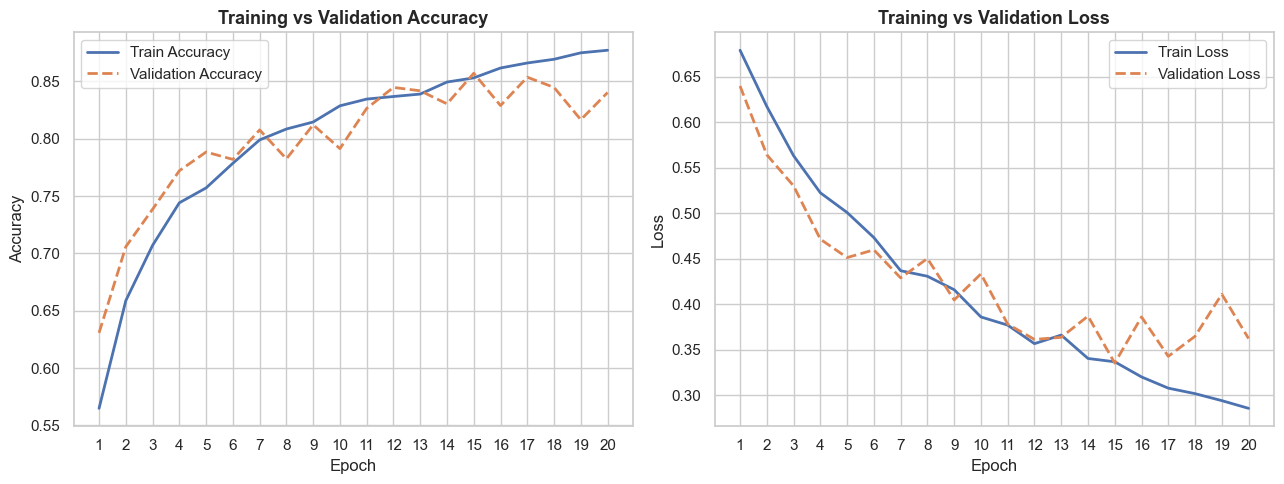

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history.history["accuracy"],     label="Train Accuracy",      linewidth=2)
ax1.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy",  linewidth=2, linestyle="--")
ax1.set_title("Training vs Validation Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.set_xticks(epochs_range)

ax2.plot(epochs_range, history.history["loss"],     label="Train Loss",      linewidth=2)
ax2.plot(epochs_range, history.history["val_loss"], label="Validation Loss",  linewidth=2, linestyle="--")
ax2.set_title("Training vs Validation Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_xticks(epochs_range)

plt.tight_layout()
plt.savefig("CNN Training Curves.png", dpi=150, bbox_inches="tight")
plt.show()

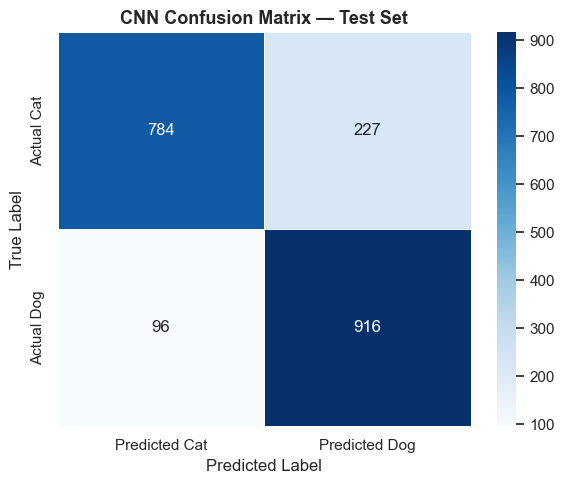

In [9]:
test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Cat", "Predicted Dog"],
    yticklabels=["Actual Cat",    "Actual Dog"],
    ax=ax,
    linewidths=0.5,
)
ax.set_title("CNN Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("CNN Matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("Classification Report")
print("=" * 55)
report_str = classification_report(
    y_true, y_pred,
    target_names=["Cat (0)", "Dog (1)"],
)
print(report_str)

report_dict = classification_report(
    y_true, y_pred,
    target_names=["Cat (0)", "Dog (1)"],
    output_dict=True,
)

cnn_metrics = {
    "Accuracy":           round(accuracy_score(y_true, y_pred), 4),
    "Weighted Precision": round(report_dict["weighted avg"]["precision"], 4), # type: ignore
    "Weighted Recall":    round(report_dict["weighted avg"]["recall"],    4), # type: ignore
    "Weighted F1":        round(report_dict["weighted avg"]["f1-score"],  4), # type: ignore
}

print("Summary Metrics")
print("-" * 35)
for metric, value in cnn_metrics.items():
    print(f"  {metric:<22}: {value:.4f}")

Classification Report
              precision    recall  f1-score   support

     Cat (0)       0.89      0.78      0.83      1011
     Dog (1)       0.80      0.91      0.85      1012

    accuracy                           0.84      2023
   macro avg       0.85      0.84      0.84      2023
weighted avg       0.85      0.84      0.84      2023

Summary Metrics
-----------------------------------
  Accuracy              : 0.8403
  Weighted Precision    : 0.8461
  Weighted Recall       : 0.8403
  Weighted F1           : 0.8397


## 7) Conclusion

This notebook demonstrated a complete CNN pipeline for binary image classification on the Cats vs Dogs dataset.

**Key takeaways:**

- A lightweight three-block CNN (32 → 64 → 128 filters) with Dropout is sufficient to achieve strong test accuracy on a balanced ~10 000-image dataset.
- Training augmentation (horizontal flip, zoom, rotation) helps the model generalise beyond the exact training images.
- Evaluation mirrors the report style of Project 1: a confusion-matrix heatmap, a full `classification_report`, and a `cnn_metrics` summary dictionary.

**Potential improvements:**

- Increase image resolution (e.g., 128 × 128) for richer spatial features.
- Use transfer learning with a pretrained backbone such as MobileNetV2 for significantly higher accuracy with fewer training epochs.
- Add `EarlyStopping` and `ReduceLROnPlateau` callbacks to prevent overfitting automatically.